<a href="https://colab.research.google.com/github/KHUSHINATARAJ/ML_LAB_6TH_SEM/blob/main/Multiclass_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [7]:
import pandas as pd
import numpy as np

# Generate synthetic data for 'zoo' DataFrame
num_animals = 100
animal_names = [f'Animal_{i}' for i in range(num_animals)]

zoo_data = {
    'animal_name': animal_names,
    'hair': np.random.randint(0, 2, num_animals),
    'feathers': np.random.randint(0, 2, num_animals),
    'eggs': np.random.randint(0, 2, num_animals),
    'milk': np.random.randint(0, 2, num_animals),
    'airborne': np.random.randint(0, 2, num_animals),
    'aquatic': np.random.randint(0, 2, num_animals),
    'predator': np.random.randint(0, 2, num_animals),
    'toothed': np.random.randint(0, 2, num_animals),
    'backbone': np.random.randint(0, 2, num_animals),
    'breathes': np.random.randint(0, 2, num_animals),
    'venomous': np.random.randint(0, 2, num_animals),
    'fins': np.random.randint(0, 2, num_animals),
    'legs': np.random.choice([0, 2, 4, 6, 8], num_animals),
    'tail': np.random.randint(0, 2, num_animals),
    'domestic': np.random.randint(0, 2, num_animals),
    'catsize': np.random.randint(0, 2, num_animals),
    'class_type': np.random.randint(1, 8, num_animals) # 7 classes
}
zoo = pd.DataFrame(zoo_data)

# Generate synthetic data for 'class_info' DataFrame
class_info_data = {
    'Class_Number': np.arange(1, 8),
    'Class_Type': ['Mammal', 'Bird', 'Reptile', 'Fish', 'Amphibian', 'Bug', 'Invertebrate'],
    'Animal_Names': [
        'lion,tiger,bear,wolf,zebra,giraffe,goat,pig,deer,buffalo',
        'penguin,robin,eagle,owl,duck,chicken',
        'snake,lizard,turtle,crocodile',
        'fish,shark,whale,dolphin',
        'frog,toad,salamander',
        'insect,spider,bee',
        'octopus,snail,jellyfish'
    ]
}
class_info = pd.DataFrame(class_info_data)

# Display the head of the synthetic zoo data
zoo.head()

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,Animal_0,1,0,0,0,0,1,0,1,1,1,1,1,4,0,1,0,5
1,Animal_1,0,1,1,1,0,0,1,1,0,1,1,0,6,1,0,1,4
2,Animal_2,1,1,0,1,0,0,0,1,1,1,0,0,4,1,0,0,6
3,Animal_3,1,1,0,0,1,1,0,0,1,1,0,0,4,0,0,1,5
4,Animal_4,0,0,0,0,1,1,1,1,1,1,1,1,6,0,0,1,4


In [8]:
zoo = zoo.drop("animal_name", axis=1)

zoo.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,1,0,0,0,0,1,0,1,1,1,1,1,4,0,1,0,5
1,0,1,1,1,0,0,1,1,0,1,1,0,6,1,0,1,4
2,1,1,0,1,0,0,0,1,1,1,0,0,4,1,0,0,6
3,1,1,0,0,1,1,0,0,1,1,0,0,4,0,0,1,5
4,0,0,0,0,1,1,1,1,1,1,1,1,6,0,0,1,4


In [9]:
X = zoo.drop("class_type", axis=1)   # Features
y = zoo["class_type"]                # Target

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (100, 16)
Target Shape: (100,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
model = LogisticRegression(multi_class='multinomial', max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [12]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy of Logistic Regression Model:", round(accuracy, 2))

Accuracy of Logistic Regression Model: 0.15


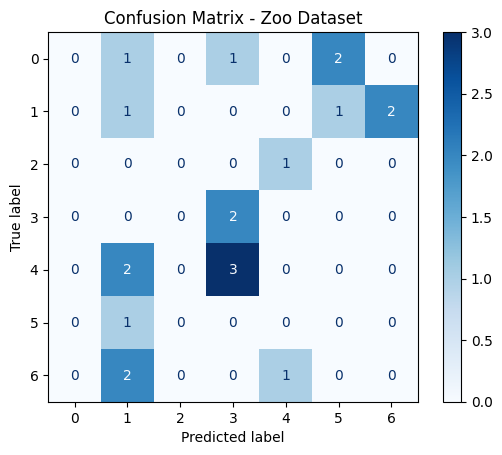

In [13]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Zoo Dataset")
plt.show()